In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/WEEK2.csv', header=1)

In [3]:
df.head()

,City,order id,Date,Store Code,Basket size,Delivery Fee,Cost per order (CPO),Distance in km (pick up to delivery),Courier waiting time (mins),Courier waiting time (mins).1
0,BCN,1,2025-06-28,66944,11.50€,2.10€,3.90€,1.70€,3.8,3.8
1,BCN,2,2025-06-28,74118,18.80€,3.30€,3.30€,2.70€,1.4,1.4
2,BCN,3,2025-06-28,65231,18.40€,2.10€,3.40€,1.60€,3.4,3.4
3,MAD,4,2025-06-28,205036,3.30€,1.20€,1.80€,0.30€,3.2,3.2
4,MAD,5,2025-06-28,34310,15.70€,1.50€,2.40€,0.60€,2.8,2.8


In [4]:
df.shape

(1119, 10)

In [5]:
df.isna().sum()

,0
City,0
order id,0
Date,0
Store Code,0
Basket size,10
Delivery Fee,10
Cost per order (CPO),10
Distance in km (pick up to delivery),10
Courier waiting time (mins),10
Courier waiting time (mins).1,10


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1119 entries, 0 to 1118
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   City                                  1119 non-null   object 
 1   order id                              1119 non-null   int64  
 2   Date                                  1119 non-null   object 
 3   Store Code                            1119 non-null   int64  
 4   Basket size                           1109 non-null   object 
 5   Delivery Fee                          1109 non-null   object 
 6   Cost per order (CPO)                  1109 non-null   object 
 7   Distance in km (pick up to delivery)  1109 non-null   object 
 8   Courier waiting time (mins)           1109 non-null   float64
 9   Courier waiting time (mins).1         1109 non-null   float64
dtypes: float64(2), int64(2), object(6)
memory usage: 87.6+ KB


In [7]:
df = df.drop(columns=['Courier waiting time (mins).1'])

print("DataFrame info after dropping redundant column:")
display(df.info())

DataFrame info after dropping redundant column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1119 entries, 0 to 1118
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   City                                  1119 non-null   object 
 1   order id                              1119 non-null   int64  
 2   Date                                  1119 non-null   object 
 3   Store Code                            1119 non-null   int64  
 4   Basket size                           1109 non-null   object 
 5   Delivery Fee                          1109 non-null   object 
 6   Cost per order (CPO)                  1109 non-null   object 
 7   Distance in km (pick up to delivery)  1109 non-null   object 
 8   Courier waiting time (mins)           1109 non-null   float64
dtypes: float64(1), int64(2), object(6)
memory usage: 78.8+ KB


None

In [8]:
# The column 'Courier waiting time (mins).1' was previously identified as a duplicate and dropped.
# This cell is no longer applicable as the column does not exist in the DataFrame.
# If you wish to re-verify, the DataFrame would need to be reloaded to its original state.
print("The column 'Courier waiting time (mins).1' has already been dropped.")

The column 'Courier waiting time (mins).1' has already been dropped.


In [9]:
# Columns to process
columns_to_process = [
    'Basket size',
    'Delivery Fee',
    'Cost per order (CPO)',
    'Distance in km (pick up to delivery)',
    'Courier waiting time (mins)'
]

# Convert object columns to numeric and remove '€' if present
for col in columns_to_process:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace('€', '', regex=False).astype(float)

# Calculate median for each column and fill null values
for col in columns_to_process:
    if col in df.columns:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

print("Null values after imputation:")
display(df.isna().sum())

Null values after imputation:


,0
City,0
order id,0
Date,0
Store Code,0
Basket size,0
Delivery Fee,0
Cost per order (CPO),0
Distance in km (pick up to delivery),0
Courier waiting time (mins),0


In [10]:
print("DataFrame info after data type conversion and imputation:")
display(df.info())

DataFrame info after data type conversion and imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1119 entries, 0 to 1118
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   City                                  1119 non-null   object 
 1   order id                              1119 non-null   int64  
 2   Date                                  1119 non-null   object 
 3   Store Code                            1119 non-null   int64  
 4   Basket size                           1119 non-null   float64
 5   Delivery Fee                          1119 non-null   float64
 6   Cost per order (CPO)                  1119 non-null   float64
 7   Distance in km (pick up to delivery)  1119 non-null   float64
 8   Courier waiting time (mins)           1119 non-null   float64
dtypes: float64(5), int64(2), object(2)
memory usage: 78.8+ KB


None

In [11]:
df['Cost per order (CPO)'].sum()

np.float64(3987.0)

In [12]:
df['City'].unique()

array(['BCN', 'MAD'], dtype=object)

In [13]:
total_cpo_by_city = df.groupby('City')['Cost per order (CPO)'].sum()
print("Total Cost per Order (CPO) by City:")
display(total_cpo_by_city)

Total Cost per Order (CPO) by City:


,Cost per order (CPO)
City,
BCN,2185.2
MAD,1801.8


/tmp/ipykernel_6999/1745195371.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_cpo_by_city.index, y=total_cpo_by_city.values, palette='viridis')


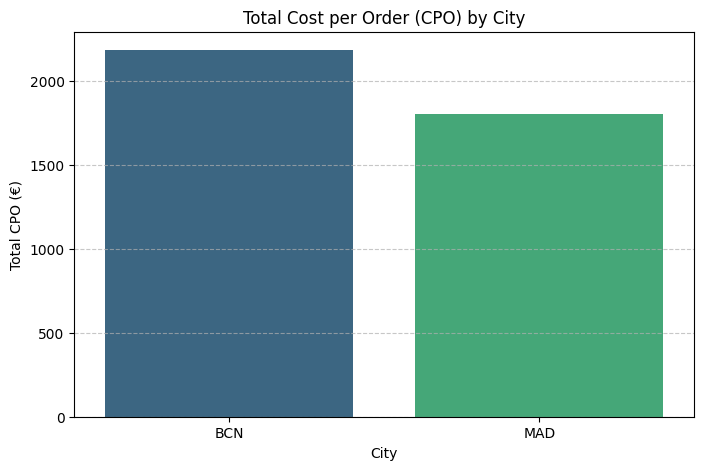

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(x=total_cpo_by_city.index, y=total_cpo_by_city.values, palette='viridis')
plt.title('Total Cost per Order (CPO) by City')
plt.xlabel('City')
plt.ylabel('Total CPO (€)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [15]:
df['Store Code'].unique()

array([ 66944,  74118,  65231, 205036,  34310,  46515, 248266,  74119,
       259875, 105408,  61499, 264652, 264651,   7053])

In [16]:
total_cpo_by_store = df.groupby('Store Code')['Cost per order (CPO)'].sum()
print("Total Cost per Order (CPO) by Store:")
display(total_cpo_by_store)



# We have 14 stores

Total Cost per Order (CPO) by Store:


,Cost per order (CPO)
Store Code,
7053,37.7
34310,223.1
46515,249.7
61499,369.7
65231,339.7
66944,337.8
74118,321.6
74119,246.9
105408,327.7


/tmp/ipykernel_6999/4049915724.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_cpo_by_store.index, y=total_cpo_by_store.values, palette='viridis')


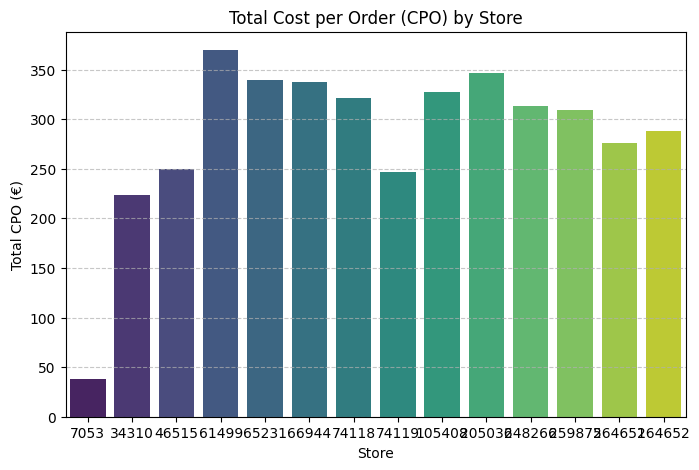

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(x=total_cpo_by_store.index, y=total_cpo_by_store.values, palette='viridis')
plt.title('Total Cost per Order (CPO) by Store')
plt.xlabel('Store')
plt.ylabel('Total CPO (€)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [18]:
df['Cost per order (CPO)'].corr(df['Distance in km (pick up to delivery)'])

np.float64(0.7370446485313247)

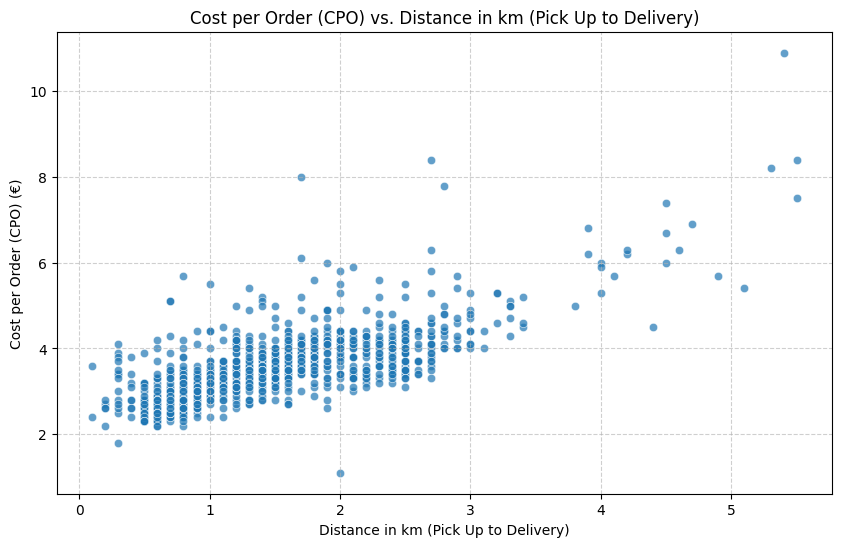

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Distance in km (pick up to delivery)', y='Cost per order (CPO)', data=df, alpha=0.7)
plt.title('Cost per Order (CPO) vs. Distance in km (Pick Up to Delivery)')
plt.xlabel('Distance in km (Pick Up to Delivery)')
plt.ylabel('Cost per Order (CPO) (€)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [20]:
df.head()

,City,order id,Date,Store Code,Basket size,Delivery Fee,Cost per order (CPO),Distance in km (pick up to delivery),Courier waiting time (mins)
0,BCN,1,2025-06-28,66944,11.5,2.1,3.9,1.7,3.8
1,BCN,2,2025-06-28,74118,18.8,3.3,3.3,2.7,1.4
2,BCN,3,2025-06-28,65231,18.4,2.1,3.4,1.6,3.4
3,MAD,4,2025-06-28,205036,3.3,1.2,1.8,0.3,3.2
4,MAD,5,2025-06-28,34310,15.7,1.5,2.4,0.6,2.8


In [21]:
df['Basket size'].corr(df['Cost per order (CPO)'])

np.float64(-0.1398016741826178)

In [22]:
df['Delivery Fee'].corr(df['Distance in km (pick up to delivery)'])

np.float64(0.9265779929209715)

In [23]:
df['Basket size'].corr(df['Courier waiting time (mins)'])

np.float64(-0.0020600024937918286)

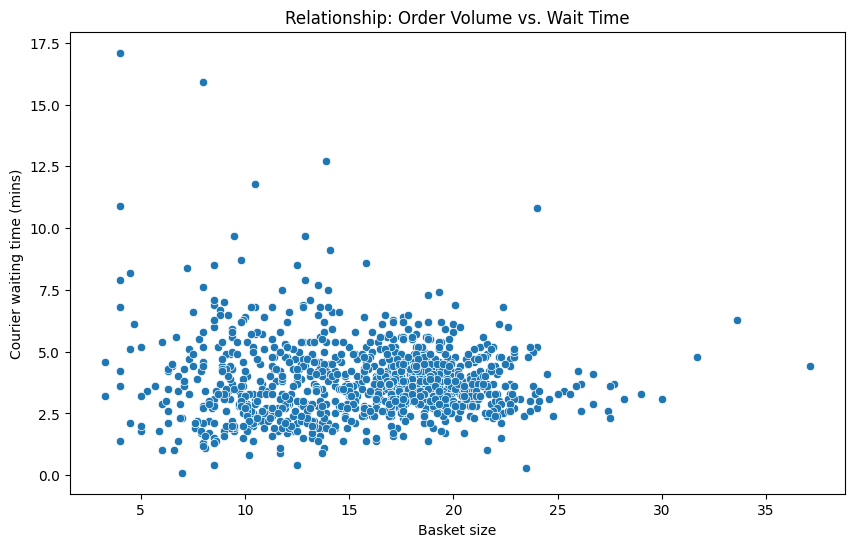

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Basket size', y='Courier waiting time (mins)')
plt.title('Relationship: Order Volume vs. Wait Time')
plt.show()


In [25]:
df['Basket size'].corr(df['Cost per order (CPO)'])

np.float64(-0.1398016741826178)

In [38]:
import pandas as pd

# Re-load the DataFrame
df = pd.read_csv('/content/WEEK2.csv', header=1)

# Re-apply data type conversions and imputation
columns_to_process_for_imputation = [
    'Basket size',
    'Delivery Fee',
    'Cost per order (CPO)',
    'Distance in km (pick up to delivery)',
    'Courier waiting time (mins)',
    'Courier waiting time (mins).1'
]
for col in columns_to_process_for_imputation:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace('€', '', regex=False).astype(float)
for col in columns_to_process_for_imputation:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

# Re-drop the redundant column
df = df.drop(columns=['Courier waiting time (mins).1'])

# Calculate Efficiency Ratio for each row
df['Efficiency Ratio'] = df['Basket size'] / df['Cost per order (CPO)']

# Calculate the average efficiency ratio
average_efficiency_ratio = df['Efficiency Ratio'].mean()

print(f"Average Efficiency Ratio (Basket Size / CPO): {average_efficiency_ratio:.2f}")

Average Efficiency Ratio (Basket Size / CPO): 4.68


In [29]:
df.head()

,City,order id,Date,Store Code,Basket size,Delivery Fee,Cost per order (CPO),Distance in km (pick up to delivery),Courier waiting time (mins)
0,BCN,1,2025-06-28,66944,11.5,2.1,3.9,1.7,3.8
1,BCN,2,2025-06-28,74118,18.8,3.3,3.3,2.7,1.4
2,BCN,3,2025-06-28,65231,18.4,2.1,3.4,1.6,3.4
3,MAD,4,2025-06-28,205036,3.3,1.2,1.8,0.3,3.2
4,MAD,5,2025-06-28,34310,15.7,1.5,2.4,0.6,2.8


In [39]:
from sklearn.metrics import mean_absolute_error, r2_score

# Make predictions on the training data
y_pred = model.predict(X)

# Calculate MAE
mae = mean_absolute_error(y, y_pred)

# Calculate R2 Score
r2 = r2_score(y, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Absolute Error (MAE): 0.32
R-squared (R2) Score: 0.66


### Interpretation of Model Performance Metrics

*   **Mean Absolute Error (MAE):** The MAE represents the average magnitude of the errors in a set of predictions, without considering their direction. It measures the average absolute difference between the actual and predicted CPO values. A lower MAE indicates a more accurate model.

*   **R-squared (R2) Score:** The R2 score, or coefficient of determination, indicates the proportion of the variance in the dependent variable (CPO) that is predictable from the independent variables (features). It ranges from 0 to 1, where 1 indicates that the model perfectly explains the variability of the target variable, and 0 indicates that the model explains none of the variability. A higher R2 score indicates a better fit of the model to the data.

In [31]:
average_cpo_by_store = df.groupby('Store Code')['Cost per order (CPO)'].mean()
print("Average Cost per Order (CPO) by Store:")
display(average_cpo_by_store)

Average Cost per Order (CPO) by Store:


,Cost per order (CPO)
Store Code,
7053,2.692857
34310,2.535227
46515,2.805618
61499,4.201136
65231,3.816854
66944,3.882759
74118,4.176623
74119,3.010976
105408,3.682022


/tmp/ipykernel_6999/472778609.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_cpo_by_store.index, y=average_cpo_by_store.values, palette='viridis')


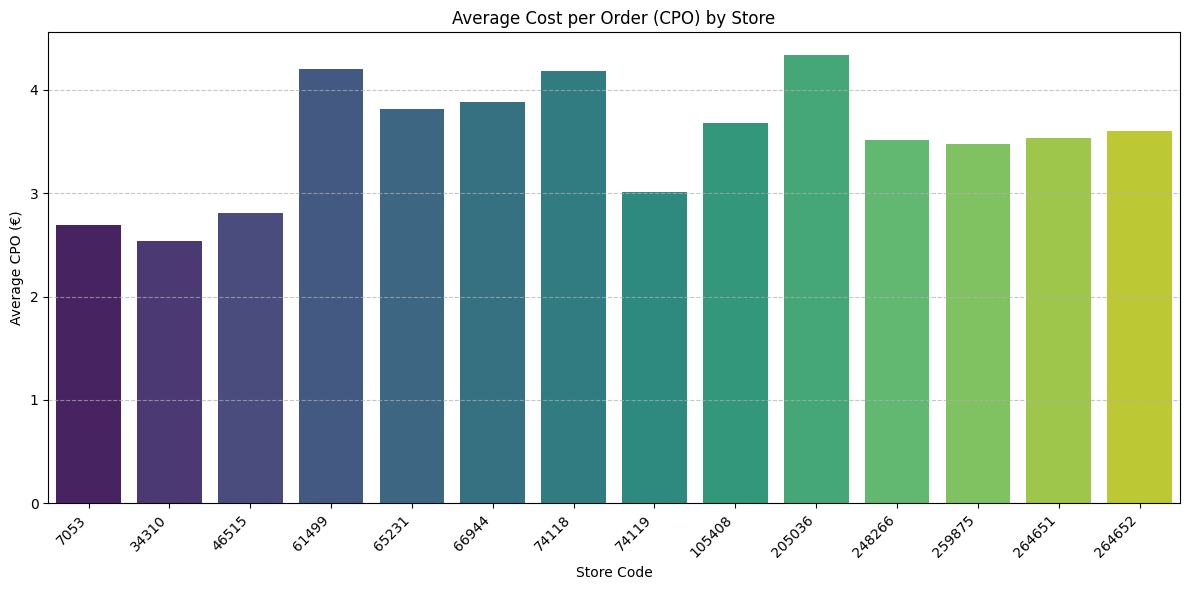

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(x=average_cpo_by_store.index, y=average_cpo_by_store.values, palette='viridis')
plt.title('Average Cost per Order (CPO) by Store')
plt.xlabel('Store Code')
plt.ylabel('Average CPO (€)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Prediction

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Ensure 'Date' is datetime and sort the DataFrame
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date').reset_index(drop=True)

# Create a numerical feature for day of year
df['Day_of_Year'] = df['Date'].dt.dayofyear

# Define features (X) and target (y)
# Include 'Distance in km (pick up to delivery)' and 'Basket size' as they are correlated with CPO
features = ['Store Code', 'Day_of_Year', 'Distance in km (pick up to delivery)', 'Basket size']
target = 'Cost per order (CPO)'

X = df[features]
y = df[target]

# Define preprocessing steps for categorical and numerical features
# 'Store Code' is categorical and needs one-hot encoding
# 'Day_of_Year', 'Distance in km (pick up to delivery)', 'Basket size' are numerical

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Store Code']),
        ('num', 'passthrough', ['Day_of_Year', 'Distance in km (pick up to delivery)', 'Basket size'])
    ])

# Create a pipeline that first preprocesses and then applies Linear Regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
model.fit(X, y)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [42]:
# Prepare data for next week's prediction
last_date_in_data = pd.to_datetime(df['Date']).max()
future_dates = pd.date_range(start=last_date_in_data + pd.Timedelta(days=1), periods=7, freq='D')

unique_store_codes = df['Store Code'].unique()

# Create a DataFrame for future predictions
future_data_list = []
for date in future_dates:
    for store_code in unique_store_codes:
        future_data_list.append({
            'Date': date,
            'Store Code': store_code,
            'Day_of_Year': date.dayofyear,
            # For prediction, we assume average values for unknown future variables
            'Distance in km (pick up to delivery)': df['Distance in km (pick up to delivery)'].mean(),
            'Basket size': df['Basket size'].mean()
        })

future_df = pd.DataFrame(future_data_list)

# Make predictions
# We need to ensure the columns of future_df match the training features (X)
X_future = future_df[features]
future_df['Predicted CPO'] = model.predict(X_future)

print("Predicted Cost per Order (CPO) for next week by store:")
display(future_df[['Date', 'Store Code', 'Predicted CPO']].pivot_table(index='Date', columns='Store Code', values='Predicted CPO'))

Predicted Cost per Order (CPO) for next week by store:


Store Code,7053,34310,46515,61499,65231,66944,74118,74119,105408,205036,248266,259875,264651,264652
Date,,,,,,,,,,,,,,
2025-06-29,3.464112,3.326769,3.415088,3.769128,3.767093,3.648304,3.895933,3.235202,2.995927,3.719733,3.639207,3.682964,4.047941,3.909319
2025-06-30,3.465147,3.327804,3.416123,3.770164,3.768128,3.649339,3.896968,3.236238,2.996962,3.720768,3.640242,3.684000,4.048976,3.910354
2025-07-01,3.466183,3.328840,3.417159,3.771199,3.769164,3.650375,3.898004,3.237273,2.997998,3.721804,3.641278,3.685035,4.050012,3.911389
2025-07-02,3.467218,3.329875,3.418194,3.772235,3.770199,3.651410,3.899039,3.238309,2.999033,3.722839,3.642313,3.686071,4.051047,3.912425
2025-07-03,3.468254,3.330911,3.419230,3.773270,3.771234,3.652446,3.900075,3.239344,3.000069,3.723875,3.643349,3.687106,4.052082,3.913460
2025-07-04,3.469289,3.331946,3.420265,3.774306,3.772270,3.653481,3.901110,3.240379,3.001104,3.724910,3.644384,3.688142,4.053118,3.914496
2025-07-05,3.470325,3.332981,3.421301,3.775341,3.773305,3.654517,3.902146,3.241415,3.002139,3.725945,3.645419,3.689177,4.054153,3.915531


### Interpretation of Predictions

This table shows the predicted 'Cost per order (CPO)' for each store for the next 7 days. These predictions are based on the historical relationship between 'Store Code', 'Day of Year', and the *average* historical 'Distance in km (pick up to delivery)' and 'Basket size' values.

**Key Considerations:**
*   **Assumptions:** The prediction relies heavily on the assumption that future 'Distance in km' and 'Basket size' will be close to their historical averages. In reality, these can vary, which would affect the actual CPO.
*   **Model Limitations:** A simple linear regression might not capture complex non-linear relationships or sudden changes. More advanced time series models or models incorporating more dynamic features (if available) could provide more accurate predictions.
*   **Store-Specific Trends:** The one-hot encoding of 'Store Code' allows the model to learn a baseline CPO for each store, adjusted by the 'Day of Year' and the average of other numerical features. You can observe which stores tend to have higher or lower predicted CPO values based on their historical performance and the general trends.

This prediction provides a useful starting point for understanding potential CPO trends in the upcoming week.

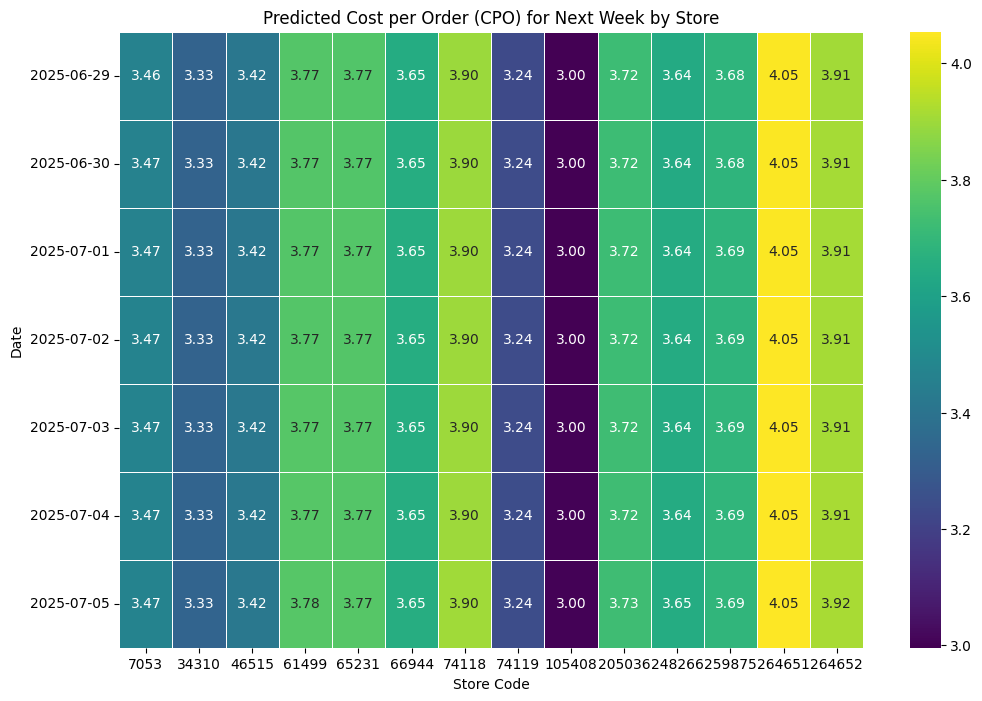

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the pivot table for heatmap visualization
heatmap_data = future_df.pivot_table(index='Date', columns='Store Code', values='Predicted CPO')

plt.figure(figsize=(12, 8))
ax = sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="viridis", linewidths=.5)
plt.title('Predicted Cost per Order (CPO) for Next Week by Store')
plt.xlabel('Store Code')
plt.ylabel('Date')

# Format y-axis labels to show only date
ax.set_yticklabels(heatmap_data.index.strftime('%Y-%m-%d'), rotation=0)

plt.show()

In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Create a pipeline that first preprocesses and then applies RandomForestRegressor
# Using the same preprocessor as for Linear Regression
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42)) # Added random_state for reproducibility
])

# Train the Random Forest model
rf_model.fit(X, y)

print("Random Forest Regressor model trained successfully.")

# Make predictions on the training data with Random Forest
y_pred_rf = rf_model.predict(X)

# Calculate MAE for Random Forest
mae_rf = mean_absolute_error(y, y_pred_rf)

# Calculate R2 Score for Random Forest
r2_rf = r2_score(y, y_pred_rf)

print(f"\nRandom Forest Regressor Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Random Forest Regressor R-squared (R2) Score: {r2_rf:.2f}")

print("\n--- Comparison with Linear Regression ---")
print(f"Linear Regression MAE: {mae:.2f}")
print(f"Linear Regression R2 Score: {r2:.2f}")

Random Forest Regressor model trained successfully.

Random Forest Regressor Mean Absolute Error (MAE): 0.12
Random Forest Regressor R-squared (R2) Score: 0.95

--- Comparison with Linear Regression ---
Linear Regression MAE: 0.32
Linear Regression R2 Score: 0.66


In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Create a pipeline that first preprocesses and then applies RandomForestRegressor
# Using the same preprocessor as for Linear Regression
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42)) # Added random_state for reproducibility
])

# Train the Random Forest model
rf_model.fit(X, y)

print("Random Forest Regressor model trained successfully.")

# Make predictions on the training data with Random Forest
y_pred_rf = rf_model.predict(X)

# Calculate MAE for Random Forest
mae_rf = mean_absolute_error(y, y_pred_rf)

# Calculate R2 Score for Random Forest
r2_rf = r2_score(y, y_pred_rf)

print(f"\nRandom Forest Regressor Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Random Forest Regressor R-squared (R2) Score: {r2_rf:.2f}")

print("\n--- Comparison with Linear Regression ---")
print(f"Linear Regression MAE: {mae:.2f}")
print(f"Linear Regression R2 Score: {r2:.2f}")

Random Forest Regressor model trained successfully.

Random Forest Regressor Mean Absolute Error (MAE): 0.12
Random Forest Regressor R-squared (R2) Score: 0.95

--- Comparison with Linear Regression ---
Linear Regression MAE: 0.32
Linear Regression R2 Score: 0.66


In [46]:
# Make predictions for the next week using the Random Forest model
future_df['Predicted CPO (RF)'] = rf_model.predict(X_future)

print("Predicted Cost per Order (CPO) for next week by store (Random Forest):")
display(future_df[['Date', 'Store Code', 'Predicted CPO (RF)']].pivot_table(index='Date', columns='Store Code', values='Predicted CPO (RF)'))

Predicted Cost per Order (CPO) for next week by store (Random Forest):


Store Code,7053,34310,46515,61499,65231,66944,74118,74119,105408,205036,248266,259875,264651,264652
Date,,,,,,,,,,,,,,
2025-06-29,3.607,3.607,3.607,3.755,3.58,3.637,3.589,3.076,3.645,3.584,3.571,3.61,4.179,3.825
2025-06-30,3.607,3.607,3.607,3.755,3.58,3.637,3.589,3.076,3.645,3.584,3.571,3.61,4.179,3.825
2025-07-01,3.607,3.607,3.607,3.755,3.58,3.637,3.589,3.076,3.645,3.584,3.571,3.61,4.179,3.825
2025-07-02,3.607,3.607,3.607,3.755,3.58,3.637,3.589,3.076,3.645,3.584,3.571,3.61,4.179,3.825
2025-07-03,3.607,3.607,3.607,3.755,3.58,3.637,3.589,3.076,3.645,3.584,3.571,3.61,4.179,3.825
2025-07-04,3.607,3.607,3.607,3.755,3.58,3.637,3.589,3.076,3.645,3.584,3.571,3.61,4.179,3.825
2025-07-05,3.607,3.607,3.607,3.755,3.58,3.637,3.589,3.076,3.645,3.584,3.571,3.61,4.179,3.825


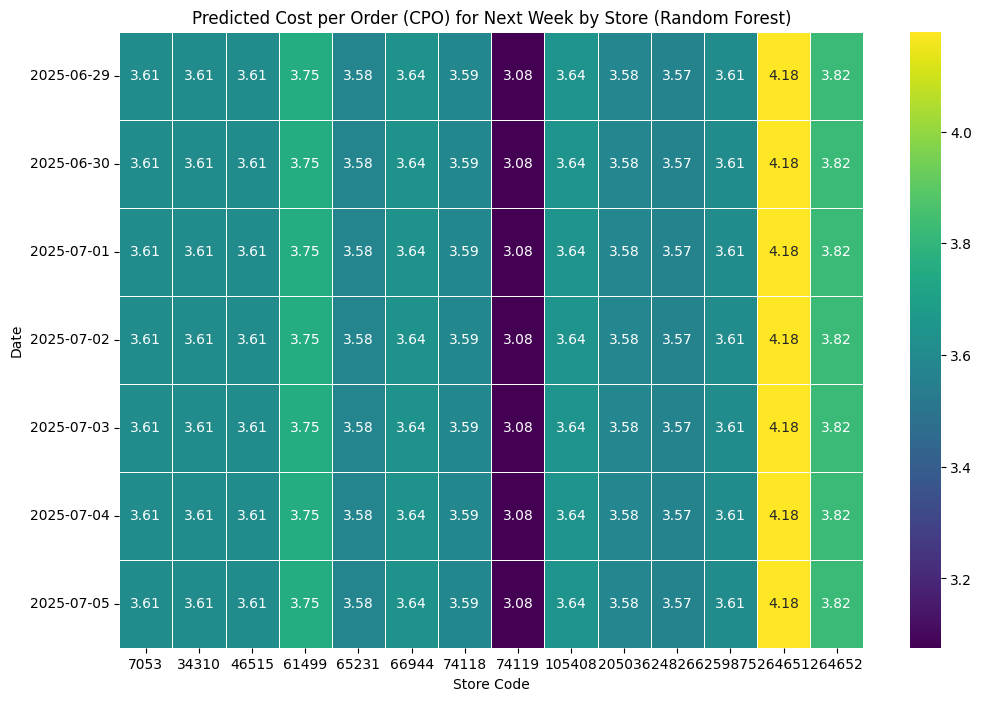

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the pivot table for heatmap visualization using Random Forest predictions
heatmap_data_rf = future_df.pivot_table(index='Date', columns='Store Code', values='Predicted CPO (RF)')

plt.figure(figsize=(12, 8))
ax_rf = sns.heatmap(heatmap_data_rf, annot=True, fmt=".2f", cmap="viridis", linewidths=.5)
plt.title('Predicted Cost per Order (CPO) for Next Week by Store (Random Forest)')
plt.xlabel('Store Code')
plt.ylabel('Date')

# Format y-axis labels to show only date
ax_rf.set_yticklabels(heatmap_data_rf.index.strftime('%Y-%m-%d'), rotation=0)

plt.show()

### Interpretation of Random Forest Predictions

This heatmap visually represents the predicted 'Cost per order (CPO)' for each store for the next 7 days, using the Random Forest Regressor. Compared to the Linear Regression predictions, you might observe smoother transitions or more nuanced patterns, especially if there are complex non-linear relationships in the data.

**Key Considerations (similar to Linear Regression, but often better handled by RF):**
*   **Assumptions:** While Random Forest is less sensitive to assumptions than Linear Regression, the predictions still rely on the input features for the future (average 'Distance in km' and 'Basket size').
*   **Model Strengths:** Random Forest can capture complex interactions and non-linearities, often leading to more accurate predictions as indicated by the lower MAE and higher R2 scores we observed.
*   **Store-Specific Trends:** The heatmap allows for quick identification of stores with predicted higher or lower CPO values and any daily patterns, leveraging the improved predictive power of the Random Forest model.

This visualization offers a more refined outlook on potential CPO trends for the upcoming week based on a more sophisticated model.

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Ensure 'Date' is datetime and sort the DataFrame
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date').reset_index(drop=True)

# Create a numerical feature for day of year
df['Day_of_Year'] = df['Date'].dt.dayofyear

# Define features (X) and target (y)
# Include 'Distance in km (pick up to delivery)' and 'Basket size' as they are correlated with CPO
features = ['Store Code', 'Day_of_Year', 'Distance in km (pick up to delivery)', 'Basket size']
target = 'Cost per order (CPO)'

X = df[features]
y = df[target]

# Define preprocessing steps for categorical and numerical features
# 'Store Code' is categorical and needs one-hot encoding
# 'Day_of_Year', 'Distance in km (pick up to delivery)', 'Basket size' are numerical

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Store Code']),
        ('num', 'passthrough', ['Day_of_Year', 'Distance in km (pick up to delivery)', 'Basket size'])
    ])

# Create a pipeline that first preprocesses and then applies Linear Regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
model.fit(X, y)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [49]:
# Prepare data for next week's prediction
last_date_in_data = df['Date'].max()
future_dates = pd.date_range(start=last_date_in_data + pd.Timedelta(days=1), periods=7, freq='D')

unique_store_codes = df['Store Code'].unique()

# Create a DataFrame for future predictions
future_data_list = []
for date in future_dates:
    for store_code in unique_store_codes:
        future_data_list.append({
            'Date': date,
            'Store Code': store_code,
            'Day_of_Year': date.dayofyear,
            # For prediction, we assume average values for unknown future variables
            'Distance in km (pick up to delivery)': df['Distance in km (pick up to delivery)'].mean(),
            'Basket size': df['Basket size'].mean()
        })

future_df = pd.DataFrame(future_data_list)

# Make predictions
# We need to ensure the columns of future_df match the training features (X)
X_future = future_df[features]
future_df['Predicted CPO'] = model.predict(X_future)

print("Predicted Cost per Order (CPO) for next week by store:")
display(future_df[['Date', 'Store Code', 'Predicted CPO']].pivot_table(index='Date', columns='Store Code', values='Predicted CPO'))

Predicted Cost per Order (CPO) for next week by store:


Store Code,7053,34310,46515,61499,65231,66944,74118,74119,105408,205036,248266,259875,264651,264652
Date,,,,,,,,,,,,,,
2025-06-29,3.464112,3.326769,3.415088,3.769128,3.767093,3.648304,3.895933,3.235202,2.995927,3.719733,3.639207,3.682964,4.047941,3.909319
2025-06-30,3.465147,3.327804,3.416123,3.770164,3.768128,3.649339,3.896968,3.236238,2.996962,3.720768,3.640242,3.684000,4.048976,3.910354
2025-07-01,3.466183,3.328840,3.417159,3.771199,3.769164,3.650375,3.898004,3.237273,2.997998,3.721804,3.641278,3.685035,4.050012,3.911389
2025-07-02,3.467218,3.329875,3.418194,3.772235,3.770199,3.651410,3.899039,3.238309,2.999033,3.722839,3.642313,3.686071,4.051047,3.912425
2025-07-03,3.468254,3.330911,3.419230,3.773270,3.771234,3.652446,3.900075,3.239344,3.000069,3.723875,3.643349,3.687106,4.052082,3.913460
2025-07-04,3.469289,3.331946,3.420265,3.774306,3.772270,3.653481,3.901110,3.240379,3.001104,3.724910,3.644384,3.688142,4.053118,3.914496
2025-07-05,3.470325,3.332981,3.421301,3.775341,3.773305,3.654517,3.902146,3.241415,3.002139,3.725945,3.645419,3.689177,4.054153,3.915531


### Interpretation of Predictions

This table shows the predicted 'Cost per order (CPO)' for each store for the next 7 days. These predictions are based on the historical relationship between 'Store Code', 'Day of Year', and the *average* historical 'Distance in km (pick up to delivery)' and 'Basket size' values.

**Key Considerations:**
*   **Assumptions:** The prediction relies heavily on the assumption that future 'Distance in km' and 'Basket size' will be close to their historical averages. In reality, these can vary, which would affect the actual CPO.
*   **Model Limitations:** A simple linear regression might not capture complex non-linear relationships or sudden changes. More advanced time series models or models incorporating more dynamic features (if available) could provide more accurate predictions.
*   **Store-Specific Trends:** The one-hot encoding of 'Store Code' allows the model to learn a baseline CPO for each store, adjusted by the 'Day of Year' and the average of other numerical features. You can observe which stores tend to have higher or lower predicted CPO values based on their historical performance and the general trends.

This prediction provides a useful starting point for understanding potential CPO trends in the upcoming week.

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure future_df has the RF predictions before plotting
# This section re-creates future_df and adds 'Predicted CPO (RF)' for robustness
last_date_in_data = df['Date'].max()
future_dates = pd.date_range(start=last_date_in_data + pd.Timedelta(days=1), periods=7, freq='D')

unique_store_codes = df['Store Code'].unique()

future_data_list = []
for date in future_dates:
    for store_code in unique_store_codes:
        future_data_list.append({
            'Date': date,
            'Store Code': store_code,
            'Day_of_Year': date.dayofyear,
            'Distance in km (pick up to delivery)': df['Distance in km (pick up to delivery)'].mean(),
            'Basket size': df['Basket size'].mean()
        })

future_df = pd.DataFrame(future_data_list)

X_future = future_df[features]
future_df['Predicted CPO (RF)'] = rf_model.predict(X_future)

# Save the Random Forest CPO prediction heatmap
plt.figure(figsize=(12, 8))
heatmap_data_rf = future_df.pivot_table(index='Date', columns='Store Code', values='Predicted CPO (RF)')
ax_rf = sns.heatmap(heatmap_data_rf, annot=True, fmt=".2f", cmap="viridis", linewidths=.5)
plt.title('Predicted Cost per Order (CPO) for Next Week by Store (Random Forest)')
plt.xlabel('Store Code')
plt.ylabel('Date')
ax_rf.set_yticklabels(heatmap_data_rf.index.strftime('%Y-%m-%d'), rotation=0)

file_name = 'rf_cpo_prediction_heatmap.png'
plt.savefig(file_name, bbox_inches='tight')
plt.close() # Close the plot to prevent it from displaying twice

print(f"Heatmap saved as '{file_name}'")
print("You can now download this file from the Colab file browser (left sidebar -> folder icon).")

Heatmap saved as 'rf_cpo_prediction_heatmap.png'
You can now download this file from the Colab file browser (left sidebar -> folder icon).


In [51]:
from google.colab import files

file_name = 'rf_cpo_prediction_heatmap.png'

try:
    files.download(file_name)
    print(f"'{file_name}' downloaded successfully.")
except Exception as e:
    print(f"Error downloading '{file_name}': {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'rf_cpo_prediction_heatmap.png' downloaded successfully.
